# 05 · One program, many machines

Parts 1 to 4 ran every program on one platform, the reference executor, and it accepts the whole language. Part 5 adds the half of the picture that was missing, the machine's own account of what it can run.

Five pieces of QProgram arrive. **`required_capabilities()`** reads off a node what that node needs. A **`PlatformCapabilities`** is where a machine writes down what it offers. **`qp.validate`** compares the two, and `qp.explain` draws the answer. **`qp.optimize`** rewrites a program the answer complains about. And **`rebind`** moves bus references when the program changes machines.

One experiment carries all of it. Part 3's flux arc fitted a sweet spot out of two nested sweeps, and 5.1 keeps one dimension of it so the plans stay short. The second dimension comes back in 5.6, and the exercise ports it.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example). 5.7 needs the two vendor packages as well.
from importlib.util import find_spec

if find_spec("qprogram") is None or find_spec("qprogram_qdac") is None:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "qprogram[viz]==0.1.0", "qprogram-qblox==0.1.0", "qprogram-qdac==0.1.0",
        ],
        check=True,
    )

from importlib.metadata import version

print("qprogram", version("qprogram"))
print("qprogram-qblox", version("qprogram-qblox"), "· qprogram-qdac", version("qprogram-qdac"))

qprogram 0.1.0
qprogram-qblox 0.1.0 · qprogram-qdac 0.1.0


In [2]:
from dataclasses import replace

import numpy as np

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusNaming, BusSchema
from qprogram.operations import Play, SetOffset, Wait
from qprogram.plotting import Quantity
from qprogram.protocol import CAPABILITY_REGISTRY
from qprogram.waveforms import IQPair, Square

schema = BusSchema.flux_tunable_transmon()
q = schema.q

## 5.0 The device

Part 5 fits nothing, so it reads only the two numbers a program has to carry: where Part 3's two-tone scan put the qubit, and where its flux fit put the bias that holds it there.

In [3]:
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, the transition at the flux sweet spot
    "flux_offset": 0.05,  # V, the bias that puts it there
}

DRIVE_FREQ = DEVICE["q0_f01"]  # park the drive tone on the sweet-spot frequency

print(f"drive parked at {DRIVE_FREQ / 1e9:.3f} GHz, sweet spot at {DEVICE['flux_offset'] * 1e3:.0f} mV")

drive parked at 4.850 GHz, sweet spot at 50 mV


## 5.1 The flux sweep

One slice of Part 3's arc: the drive parked at a fixed frequency, the bias stepped, the state read out at every point.

Two lines matter later. `set_offset` is the only operation that touches the flux bus, and `sync` is written with an explicit target list, which 5.6 is about.

In [4]:
program = qp.QProgram(label="flux_sweep", description="one slice of the Part 3 flux arc", schema=schema)
bias = program.variable("bias", label="Flux bias", units="V")

with program.average(shots=200):
    with program.sweep(bias, qp.Linspace(-0.05, 0.15, 101)):
        program.set_offset(q[0].flux, bias)
        program.set_frequency(q[0].drive, DRIVE_FREQ)
        program.play(q[0].drive, "saturation")
        program.sync([q[0].drive, q[0].readout])
        m0 = program.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(program))

#!QProgram 1.0

metadata:
  label: "flux_sweep"
  description: "one slice of the Part 3 flux arc"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  var bias label="Flux bias" units="V"

  average 200:
    for bias in Linspace(start=-0.05, stop=0.15, num=101):
      set_offset q[0].flux bias
      set_frequency q[0].drive 4850000000.0
      play q[0].drive "saturation"
      sync q[0].drive q[0].readout
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



## 5.2 `qp.validate`

`qp.validate(program, caps)` reads a program against a capability descriptor and hands back a tuple, `(diagnostics, plan)`, whatever it finds. One call then serves three callers who want different things out of a failure, an editor plugin that wants every diagnostic and no exceptions, a CI job that wants a non-zero exit, a notebook that wants to keep going and show the plan. A platform's `execute()` is the caller that turns an error into an exception.

The descriptor for the platform every part so far has run on is one call away, and an empty diagnostics list is the answer you want.

In [5]:
caps = qp.reference_capabilities()

diagnostics, plan = qp.validate(program, caps)
print("diagnostics:", diagnostics)
print("plan entries:", len(plan))

diagnostics: []
plan entries: 7


### The plan

The plan is a mapping from node to domain set, so it prints as one. `rt` is the sequencer and `host` is the lab server. The root `body` is not an entry, because there is nowhere else for it to run.

In [6]:
for node, domains in plan.items():
    print(f"{type(node).__name__:14s} {'|'.join(sorted(domains))}")

SetOffset      host|rt
SetFrequency   host|rt
Play           host|rt
Sync           host|rt
Measure        host|rt
Sweep          host|rt
Average        host|rt


### `qp.explain`

The same plan, drawn. One `.qp` line per node, its domain on the right, and any diagnostic beside it.

In [7]:
print(qp.explain(program, caps))

plan for 'flux_sweep' — errors: 0 · warnings: 0 · info: 0
body
└─ average 200:                                                                          [rt|host]
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=101):                             [rt|host]
      ├─ set_offset q[0].flux bias                                                       [rt|host]
      ├─ set_frequency q[0].drive 4850000000.0                                           [rt|host]
      ├─ play q[0].drive "saturation"                                                    [rt|host]
      ├─ sync q[0].drive q[0].readout                                                    [rt|host]
      └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt|host]


Every row reads `[rt|host]` and there is nothing annotated, because the reference platform supports the whole language. `qp.ReferencePlatform()` carries `validate`, `plan`, and `explain` as methods that take the program alone, and Part 6 works with the object that way.

## 5.3 `PlatformCapabilities`

Nothing above had to make a choice. Take one thing away from the descriptor and it does.

Three fields, and the code below touches two. `caps.bus` is keyed by `(element_kind, bus_kind)`, so `("q", "flux")` is a separate entry from `("q", "drive")`. `caps.default_bus_profile` answers for every slot that map does not list, a raw-string bus included, since a raw string carries no schema coordinate to route on. `caps.platform` answers for whatever names no bus, and 5.4 and 5.5 put it to work.

`caps.platform`, `caps.default_bus_profile`, and every entry in `caps.bus` is a `BusCapabilities`, a pair of the halves 5.2 named, and either half may be `None`. One `None` is the whole of the change below, a flux line with no sequencer behind it.

Every descriptor is a frozen dataclass, so `dataclasses.replace` gives back a copy with one field changed. It is the shortest way to write down a machine that differs from one you already have.

In [8]:
no_sequencer = replace(caps.default_bus_profile, rt=None)
rack_b = replace(caps, bus={("q", "flux"): no_sequencer})

print("rt half of the flux slot:", no_sequencer.rt)
for bus in (q[0].drive, q[0].flux):
    print(f"{bus} runs in: {sorted(rack_b.for_bus(bus).supported_domains())}")

rt half of the flux slot: None
q0/drive runs in: ['host', 'rt']
q0/flux runs in: ['host']


In [9]:
b_diagnostics, _ = qp.validate(program, rack_b)

for diag in b_diagnostics:
    print(diag)
    print()

print(qp.explain(program, rack_b))

[warning] forced-host: Block 'Average' falls back to host-side execution: contains host-side-only sub-block 'Sweep'. (at body[0])

[info] reorderable-averaging: Block 'Average' runs host-side only because it encloses a host-side sweep; its measurement sequence supports real-time hardware. Moving the sweep outside the average (hoisting the host-side-only setup with it) would let the averaging run in real-time hardware — see qprogram.optimize(). (at body[0])

plan for 'flux_sweep' — errors: 0 · warnings: 1 · info: 1
body
└─ average 200:                                                                          [host]     ~ forced-host: contains host-side-only sub-block 'Sweep'  i reorderable-averaging: Block 'Average' runs host-side only because it encloses a host-side sweep; its measurement sequence supports real-time hardware. Moving the sweep outside the average (hoisting the host-side-only setup with it) would let the averaging run in real-time hardware — see qprogram.optimize().
   └─

Nothing in the program changed and its plan did. `set_offset` routes to the flux slot, which has a host half only, so the operation reads `[host]`, the sweep holding it went host-side, and the averaging above that followed. The `forced-host` warning reports exactly that, naming the block that fell and the child that pulled it.

Severity is the field you act on here, and a warning still runs. What fell is the averaging, so the round trip is paid 200 times per bias point instead of once. The `reorderable-averaging` note is the validator saying it can see a cheaper arrangement of the same experiment, and 5.6 takes it up.

In [10]:
print("severity:", b_diagnostics[0].severity, "| code:", b_diagnostics[0].code)

severity: warning | code: forced-host


## 5.4 Tokens

Part 3 printed `required_capabilities()` off a `play` and a `set_gain` and said Part 5 is where a rack reads them. Each answer is a set of flat dotted strings, and one node gives one on its own.

In [11]:
print(sorted(Play(q[0].drive, "saturation").required_capabilities()))

['op.play', 'waveform.alias']


The same `play` asks for different tokens depending on what it is given to play. An alias asks for almost nothing, because nothing has resolved it to a shape yet.

In [12]:
pair = IQPair(Square(0.2, 100), Square(0.0, 100))
print("a Square: ", sorted(Play(q[0].drive, Square(0.2, 100)).required_capabilities()))
print("an IQPair:", sorted(Play(q[0].drive, pair).required_capabilities()))
print("an alias: ", sorted(Play(q[0].drive, "saturation").required_capabilities()))

a Square:  ['op.play', 'waveform.single', 'waveform.square']
an IQPair: ['op.play', 'waveform.iq', 'waveform.iq_pair']
an alias:  ['op.play', 'waveform.alias']


Every node in a program answers the same call, so a walk over the tree is the demand side of the whole validation in one loop.

In [13]:
for node in program.body.walk():
    print(f"{type(node).__name__:14s} {sorted(node.required_capabilities())}")

Block          ['block.block']
Average        ['block.average']
Sweep          ['block.sweep', 'sweep.linear', 'sweep.linspace']
SetOffset      ['expr.variable', 'op.set_offset']
SetFrequency   ['op.set_frequency']
Play           ['op.play', 'waveform.alias']
Sync           ['op.sync']
Measure        ['measure.fields.state', 'op.measure', 'waveform.alias', 'waveform.iq']


### Where a token is checked

The supply side is `supports`, one hash lookup on a `CompilerCapabilities`, the type each half of a slot holds.

In [14]:
reference_bus = caps.default_bus_profile

print(reference_bus.rt.supports("op.play"))

True


What picks the profile is the node rather than the token. A block, and an operation that touches no bus, is checked against the platform slot, and an operation that touches a bus is checked against that bus. One prefix routes on its own: `expr.*` always goes to the platform slot, even on an operation that does touch a bus, because it is a claim about the language rather than about the line.

The lookup is per half, and the two halves of even the permissive reference descriptor disagree. `set_parameter` writes a setting the platform holds as configuration rather than a register a sequencer owns, so a bus slot carries it in its `host` half and not in its `rt` one.

In [15]:
print(reference_bus.rt.profile, "knows", len(reference_bus.rt.capabilities), "tokens")
for token in ("op.play", "op.set_offset", "op.set_parameter"):
    print(f"{token:18s} rt {reference_bus.rt.supports(token)!s:5s} host {reference_bus.host.supports(token)}")

qprogram-reference-bus knows 65 tokens
op.play            rt True  host True
op.set_offset      rt True  host True
op.set_parameter   rt False host True


Part 2 put an attenuator write above its loops on purpose and said Part 5 has the tool that tells you when one inside a loop has dragged the loop down with it. That tool is the plan, and the descriptor it needs is the reference one, unedited.

In [16]:
def attenuation_probe(inside):
    """The Part 2 attenuator write, placed inside the sweep or above both loops."""
    prog = qp.QProgram(label="attenuation_probe", schema=schema)
    ro_freq = prog.variable("ro_freq", label="Readout frequency", units="Hz")
    if not inside:
        prog.set_parameter(q[0].readout, "attenuation", 30.0)
    with prog.average(shots=10):
        with prog.sweep(ro_freq, qp.Linspace(7.19e9, 7.21e9, 11)):
            if inside:
                prog.set_parameter(q[0].readout, "attenuation", 30.0)
            prog.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))
    return prog


for inside in (False, True):
    where = "inside the sweep" if inside else "above both loops"
    print(f"{where:16s} -> {[d.code for d in qp.validate(attenuation_probe(inside), caps)[0]] or 'no diagnostics'}")

above both loops -> no diagnostics
inside the sweep -> ['forced-host', 'reorderable-averaging']


Above the loops the write costs nothing. Inside the sweep it takes the sweep host-side and the averaging with it, and the two codes that come back are the pair rack B produced in 5.3 from a descriptor with a half removed. Nothing was removed here, and the placement of one line did it.

### A token the rack does not have

Rack C has a plain DC source on the flux line, one that takes a voltage over a serial link and has no offset register at all. Building its profile by hand needs the constructor, whose six fields are all required, and a token set to put in it. `CAPABILITY_REGISTRY` is every token the installed language knows about, so subtracting from it describes a machine that implements everything except the thing being taken away. The subtraction is a notebook shortcut rather than a real rack, and 5.7 replaces it.

In [17]:
dc_source = qp.CompilerCapabilities(
    profile="dc-source",
    version=(0, 1, 0),
    capabilities=frozenset(CAPABILITY_REGISTRY) - {"op.set_offset"},
    limits={},
    predicates=(),
    vendor_versions={},
)
rack_c = replace(caps, bus={("q", "flux"): qp.BusCapabilities(rt=None, host=dc_source)})

for diag in qp.validate(program, rack_c)[0]:
    print(diag)
    print("  severity:  ", diag.severity)
    print("  code:      ", diag.code)
    print("  capability:", diag.capability)
    print("  path:      ", diag.path, "->", qp.format_path(diag.path))

[error] missing-capability: 'SetOffset' requires capability 'op.set_offset' which is not supported by 'dc-source' (host) (at body[0][0][0])
  severity:   error
  code:       missing-capability
  capability: op.set_offset
  path:       (0, 0, 0) -> body[0][0][0]


The printout is most of a `Diagnostic`. A `severity` and a machine-readable `code` you saw in 5.3, a `message` for a person, the offending `node`, a structural `path`, and the `capability` that went missing. Two more fields fill in where a check has them, the `limit` pair 5.5 reads and the `domain` a `forced-host` warning ends up in. The message is for a terminal, the `code` is for a script deciding whether your CI should fail on this, and the `path` is for an editor putting a squiggle under the right line. Part 6 runs the same diagnostics from a shell and gets JSON.

In [18]:
print(qp.explain(program, rack_c))

plan for 'flux_sweep' — errors: 1 · warnings: 0 · info: 0
body
└─ average 200:                                                                          [rt|host]
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=101):                             [--]
      ├─ set_offset q[0].flux bias                                                       [--]       !! missing-capability: 'SetOffset' requires capability 'op.set_offset' which is not supported by 'dc-source' (host)
      ├─ set_frequency q[0].drive 4850000000.0                                           [rt|host]
      ├─ play q[0].drive "saturation"                                                    [rt|host]
      ├─ sync q[0].drive q[0].readout                                                    [rt|host]
      └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt|host]


Read that tree from the leaves up. The `set_offset` row is `[--]`, and the diagnostic sits beside it. The sweep above it is `[--]` too and carries nothing of its own, because an operation that can run nowhere empties the loop holding it. Looking on the loop's own line for a reason will not find one.

The `average` at the top still reads `[rt|host]`. In 5.3 the sweep was host-side rather than empty, and a host-side loop does pull its enclosing block host-side. An empty child does not propagate that way.

### Paths and the source map

A path is a tuple of indices into the tree. `qp.format_path` prints one, and `qp.node_path` and `qp.resolve_path` walk between a path and its node in either direction.

In [19]:
top = program.body.elements[0]
top_path = qp.node_path(program, top)

print(qp.format_path(top_path), "->", type(qp.resolve_path(program, top_path)).__name__)

body[0] -> Average


Turning a path into a line number needs a file, and `program.source_map` is the map. It arrives populated only on a program that came through `qp.loads`, because a program built in Python has no line for a node to have come from. A program you loaded needs no round trip, since loading filled the map already, and `expand()` returns a copy with an empty one, since inlining a call produces nodes no line of the file ever held.

In [20]:
print("built in Python, source_map entries:", len(program.source_map))

text = qp.dumps(program)
reloaded = qp.loads(text)
for diag in qp.validate(program, rack_c)[0]:
    if diag.path is None:
        continue
    line = reloaded.source_map[diag.path]
    print(f"{qp.format_path(diag.path)} -> line {line}: {text.splitlines()[line - 1].strip()}")

built in Python, source_map entries: 0
body[0][0][0] -> line 18: set_offset q[0].flux bias


### A diagnostic no descriptor produced

Not every check reads the capability descriptor. Part 4 built a conditional on a measurement that never asked for `MF.STATE` and got an `UnsupportedOperationError` out of the executor, and said Part 5 turns that report into something you can read before running anything. The same program through `qp.validate` gives a diagnostic instead of an exception, with a code to match on and a path to point at.

In [21]:
oops = qp.QProgram(label="oops", schema=schema)
m_iq = oops.measure(q[0].readout, "readout", "weights")  # default fields=(MF.IQ,)
with oops.if_(m_iq.state == 1):
    oops.play(q[0].drive, "pi")

for diag in qp.validate(oops, caps)[0]:
    print(f"[{diag.severity}] {diag.code} at {qp.format_path(diag.path)}")
    print("   ", diag.message)

[error] missing-classification at body[1]
    Conditional references q0/readout/m0.state, but the measurement does not request state classification (add MeasurementField.STATE to fields=)


## 5.5 Limits and predicates

`capabilities` was the field 5.4 read. The other two the constructor asked for are the rest of what a descriptor gets to say: **`limits`**, numbers the program is measured against, and **`predicates`**, callables that get to look at the rest of the program before answering.

### Limits

The validator reads four limit keys and passes over every other one. `max_loop_nesting`, `max_parallel_loops`, and `max_measurements` come off the platform slot, and `min_wait_duration_ns` off the bus a node routes to. A profile is free to publish a key outside that set, and `qdac-default-v1` in 5.7 does, so publishing a limit and enforcing it are two different things.

The flux sweep nests two loops, the averaging and the sweep. Give the platform slot a sequencer with room for one and it stops fitting. The `limit` field carries the pair `(name, observed)`, so a tool can report the number without parsing the message.

In [22]:
# Loop limits live on the platform slot, and the validator reads them off `rt` when it has one.
shallow = replace(caps.platform, rt=replace(caps.platform.rt, limits={"max_loop_nesting": 1}))
caps_shallow = replace(caps, platform=shallow)

for diag in qp.validate(program, caps_shallow)[0]:
    print(diag)
    print("  limit:", diag.limit)

[error] limit-exceeded: Program nests loops 2 deep; limit max_loop_nesting=1
  limit: ('max_loop_nesting', 2.0)


### Predicates

A predicate is a callable. It receives a node and a `ValidationContext`, it yields nothing when the node is fine, and what it yields otherwise is an ordinary `Diagnostic`. The smallest one ignores the context entirely and refuses a node type outright.

In [23]:
def refuse_play(node, ctx):
    """A rack with no waveform memory at all."""
    if isinstance(node, Play):
        yield qp.Diagnostic(
            severity="error",
            code="demo.no-play",
            message="this rack plays nothing",
            node=node,
        )


def with_predicate(slot, predicate):
    """Copy one bus slot with a predicate appended to each half that exists."""
    return qp.BusCapabilities(
        rt=None if slot.rt is None else replace(slot.rt, predicates=(*slot.rt.predicates, predicate)),
        host=None if slot.host is None else replace(slot.host, predicates=(*slot.host.predicates, predicate)),
    )


plays_nothing = replace(caps, default_bus_profile=with_predicate(caps.default_bus_profile, refuse_play))
print([str(d) for d in qp.validate(program, plays_nothing)[0]])

['[error] demo.no-play: this rack plays nothing (at body[0][0][2])']


The second argument is there for the rules a single node cannot answer. Take `wait(bus, duration)`. It accepts a variable, and rack D takes only the linear kind of sweep source behind one. `op.wait` is supported either way, and the `sweep.arbitrary` token that does separate the two sits on the loop rather than on the wait, so refusing it would refuse every arbitrary sweep on the rack instead of this one pairing. The answer lives in the binding loop, a different node several levels up and possibly not written yet when the `wait` was appended.

`ctx.sweep_kind_of(var)` is the query that closes the gap, and there are eight in all.

| Query | Returns |
|---|---|
| `ctx.sweep_kind_of(var)` | `"linear"`, `"arbitrary"`, or `None` when nothing binds the variable |
| `ctx.binding_loop_of(var)` | the `Sweep` that binds the variable, or `None` |
| `ctx.max_loop_nesting` | deepest repetition depth in the program |
| `ctx.max_parallel_arity` | widest lockstep composition in the program |
| `ctx.measurement_count` | number of measurement operations |
| `ctx.measurement_fields(name)` | the fields one measurement asked for, or `None` |
| `ctx.known_measurement_names()` | every measurement name in the program |
| `ctx.program_buses` | every bus the program touches |

In [24]:
def reject_arbitrary_wait(node, ctx):
    """Rack D's wait instruction takes a fixed-step counter, so arbitrary delay lists are out."""
    if not isinstance(node, Wait) or not isinstance(node.duration, qp.Variable):
        return
    if ctx.sweep_kind_of(node.duration) == "arbitrary":
        yield qp.Diagnostic(
            severity="error",
            code="rackd.arbitrary-wait-sweep",
            message=(
                f"Variable {node.duration.id!r} is swept with arbitrary values and used at "
                f"Wait.duration. Use Range or Linspace, or a constant duration."
            ),
            node=node,
        )


rack_d = replace(caps, default_bus_profile=with_predicate(caps.default_bus_profile, reject_arbitrary_wait))
print("predicates on rack D's drive bus, rt half:",
      [p.__name__ for p in rack_d.for_bus(q[0].drive).rt.predicates])

predicates on rack D's drive bus, rt half: ['_swept_parameter_forces_host', 'reject_arbitrary_wait']


In [25]:
def t1_program(source):
    """Part 4's inversion recovery, with the delay axis coming from whatever source you pass."""
    prog = qp.QProgram(label="t1", schema=schema)
    delay = prog.variable("delay", label="Delay", units="ns")
    with prog.average(shots=50):
        with prog.sweep(delay, source):
            prog.play(q[0].drive, "pi")
            prog.wait(q[0].drive, delay)
            prog.sync([q[0].drive, q[0].readout])
            prog.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))
    return prog


for source in (qp.Range(0, 20_000, 500), qp.Values([0, 200, 800, 3200, 12_800])):
    found = qp.validate(t1_program(source), rack_d)[0]
    print(f"{type(source).__name__:9s} {[str(d) for d in found] or 'no diagnostics'}")

Range     no diagnostics
Values    ["[error] rackd.arbitrary-wait-sweep: Variable 'delay' is swept with arbitrary values and used at Wait.duration. Use Range or Linspace, or a constant duration. (at body[0][0][1])"]


A predicate belongs to one half of one slot, exactly like a token does, so rack D takes the first of those two programs and refuses the second.

### A domain constraint instead of a refusal

Yielding a `Diagnostic` is a hard no. A predicate may yield a `DomainConstraint` instead when the answer is "not in the sequencer, but the host can do it". It names the block to restrict, the domains to take away, and a `reason` string, and the classifier subtracts that domain from the loop rather than failing the program. It is a second road to the `forced-host` warning of 5.3, reached without an empty `rt` half.

The node has to be a block rather than the operation that noticed, and the binding loop is the block worth naming. Point one at an operation and the validator answers with a `bad-domain-constraint` error of its own.

In [26]:
def dac_on_the_network(node, ctx):
    """Not a refusal. The loop that steps this DAC has to dispatch from the host."""
    if not isinstance(node, SetOffset) or not isinstance(node.offset_path0, qp.Variable):
        return
    loop = ctx.binding_loop_of(node.offset_path0)
    if loop is not None:
        yield qp.DomainConstraint(
            node=loop,
            exclude=frozenset({"rt"}),
            reason="the DAC answers over Ethernet",
        )


constrained = replace(caps, bus={("q", "flux"): with_predicate(caps.default_bus_profile, dac_on_the_network)})

for diag in qp.validate(program, constrained)[0]:
    print(f"[{diag.severity}] {diag.code}")
    print("   ", diag.message)

[warning] forced-host
    Block 'Average' falls back to host-side execution: contains host-side-only sub-block 'Sweep' (the DAC answers over Ethernet).


The flux slot here keeps both halves, and the plan still puts the sweep on the host. The reason string comes back inside the warning, at the node where the constraint changed the answer.

### A rule about your own wiring

Rack D's rule came out of an instruction set. The next one comes off a bench, since rack B's flux line stops being linear above 0.25 V, and a predicate is where that number gets written down.

`ctx.binding_loop_of` finds the sweep that binds the offset, `loop.source.values()` is that sweep's own numbers, and the rest is arithmetic. The two scans below differ only in the range they cover.

In [27]:
SAFE_VOLTS = 0.25


def flux_within_range(node, ctx):
    """Reject a flux sweep that leaves the linear range of the bias tee."""
    if not isinstance(node, SetOffset):
        return
    value = node.offset_path0
    if isinstance(value, qp.Variable):
        loop = ctx.binding_loop_of(value)
        reach = max(abs(v) for v in loop.source.values()) if loop is not None else 0.0
    else:
        reach = abs(value)
    if reach > SAFE_VOLTS:
        yield qp.Diagnostic(
            severity="error",
            code="rackb.flux-out-of-range",
            message=f"flux offset reaches {reach:.2f} V, past the {SAFE_VOLTS} V bias-tee limit",
            node=node,
        )


caps_guarded = replace(rack_b, bus={("q", "flux"): with_predicate(no_sequencer, flux_within_range)})


def bias_scan(low, high):
    """A bare flux scan over one range, for the predicate to judge."""
    prog = qp.QProgram(label="bias_scan", schema=schema)
    scan_bias = prog.variable("bias", label="Flux bias", units="V")
    with prog.average(shots=10):
        with prog.sweep(scan_bias, qp.Linspace(low, high, 11)):
            prog.set_offset(q[0].flux, scan_bias)
            prog.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))
    return prog


for low, high in ((-0.05, 0.15), (-0.40, 0.40)):
    found = qp.validate(bias_scan(low, high), caps_guarded)[0]
    errors = [str(d) for d in found if d.severity == "error"]
    print(f"{low:+.2f} V to {high:+.2f} V -> {errors or 'no errors'}")

-0.05 V to +0.15 V -> no errors
-0.40 V to +0.40 V -> ['[error] rackb.flux-out-of-range: flux offset reaches 0.40 V, past the 0.25 V bias-tee limit (at body[0][0][0])']


## 5.6 `qp.optimize`

Back to rack B, where the averaging fell host-side because it *encloses* the flux sweep, while everything it averages runs real-time. Swapping the two loops removes the reason, and `qp.optimize` is the swap.

In [28]:
optimized = qp.optimize(program, rack_b)

print("body[0] before:", type(program.body.elements[0]).__name__)
print("body[0] after: ", type(optimized.body.elements[0]).__name__)

body[0] before: Average
body[0] after:  Sweep


In [29]:
print(qp.explain(optimized, rack_b))

plan for 'flux_sweep' — errors: 0 · warnings: 0 · info: 0
body
└─ for bias in Linspace(start=-0.05, stop=0.15, num=101):                                [host]
   ├─ set_offset q[0].flux bias                                                          [host]
   └─ average 200:                                                                       [rt|host]
      ├─ set_frequency q[0].drive 4850000000.0                                           [rt|host]
      ├─ play q[0].drive "saturation"                                                    [rt|host]
      ├─ sync q[0].drive q[0].readout                                                    [rt|host]
      └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt|host]


The sweep is the outer block now, the `set_offset` has been hoisted to sit between the two, and the averaging is back in the sequencer with no warning left.

The rewrite is opt-in, because it is not unconditionally equivalent. It takes all 200 shots of one bias point before moving on, where the program as written interleaved passes over the whole sweep. The two are the same experiment for a stationary device and different under drift. When you want the interleaving, do not call `optimize`.

The hoisted `set_offset` also runs once per bias point rather than once per shot, which is right for a DC level and wrong for an operation with side effects, so the rewrite hoists only a leading run of host-side-only operations and refuses to move one past an operation it would reorder against.

### What blocks the rewrite

Both spellings of `sync` ask for the same `op.sync` token, so nothing in the token set separates them. What separates them is the bus list the validator intersects domains over, and a bare `sync()` pulls the flux line into that intersection, which puts the sync on the host in the middle of a run of real-time operations. The rewrite will not hoist across it.

The program below is 5.1 with that one line changed.

In [30]:
broadcast = qp.QProgram(label="flux_sweep", schema=schema)
b_bias = broadcast.variable("bias", label="Flux bias", units="V")

with broadcast.average(shots=200):
    with broadcast.sweep(b_bias, qp.Linspace(-0.05, 0.15, 101)):
        broadcast.set_offset(q[0].flux, b_bias)
        broadcast.set_frequency(q[0].drive, DRIVE_FREQ)
        broadcast.play(q[0].drive, "saturation")
        broadcast.sync()  # every bus, the flux line included
        broadcast.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print("targeted codes: ", [d.code for d in qp.validate(program, rack_b)[0]])
print("broadcast codes:", [d.code for d in qp.validate(broadcast, rack_b)[0]])
print("optimize rewrites the targeted program: ", qp.dumps(qp.optimize(program, rack_b)) != qp.dumps(program))
print("optimize rewrites the broadcast program:", qp.dumps(qp.optimize(broadcast, rack_b)) != qp.dumps(broadcast))
print()
print(qp.explain(broadcast, rack_b))

targeted codes:  ['forced-host', 'reorderable-averaging']
broadcast codes: ['forced-host']
optimize rewrites the targeted program:  True
optimize rewrites the broadcast program: False

plan for 'flux_sweep' — errors: 0 · warnings: 1 · info: 0
body
└─ average 200:                                                                          [host]     ~ forced-host: contains host-side-only sub-block 'Sweep'
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=101):                             [host]
      ├─ set_offset q[0].flux bias                                                       [host]
      ├─ set_frequency q[0].drive 4850000000.0                                           [rt|host]
      ├─ play q[0].drive "saturation"                                                    [rt|host]
      ├─ sync                                                                            [host]
      └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt|host]


The `sync` row is `[host]`, the `reorderable-averaging` note is gone, and `optimize` returns the program it was given. One habit, `sync()` instead of `sync([...])`, costs the whole rewrite and produces no error message anywhere.

### When it does nothing

The pattern the rewrite matches is narrow. The averaging block's only child has to be one flat sweep whose body holds no nested block. Part 3's arc is the two-dimensional version of the same experiment, and it falls outside that shape.

Its plan is also the answer Part 3 promised, since the bias sweep holds the `set_offset` and goes host-side while the frequency sweep nested inside it keeps both domains. The version below names its sync targets where Part 3 wrote a bare `sync()`, and that is what holds the inner sweep in the sequencer, so the shape of the nesting is the only thing left blocking the rewrite.

In [31]:
arc = qp.QProgram(label="flux_arc", schema=schema)
arc_bias = arc.variable("bias", label="Flux bias", units="V")
arc_freq = arc.variable("drive_freq", label="Drive frequency", units="Hz")

with arc.average(shots=50):
    with arc.sweep(arc_bias, qp.Linspace(-0.05, 0.15, 21)):
        arc.set_offset(q[0].flux, arc_bias)
        with arc.sweep(arc_freq, qp.Linspace(4.70e9, 4.90e9, 21)):
            arc.set_frequency(q[0].drive, arc_freq)
            arc.play(q[0].drive, "saturation")
            arc.sync([q[0].drive, q[0].readout])
            arc.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print("arc codes:", [d.code for d in qp.validate(arc, rack_b)[0]])
print("optimize rewrites the arc:", qp.dumps(qp.optimize(arc, rack_b)) != qp.dumps(arc))
print()
print(qp.explain(arc, rack_b))

arc codes: ['forced-host']
optimize rewrites the arc: False

plan for 'flux_arc' — errors: 0 · warnings: 1 · info: 0
body
└─ average 50:                                                                              [host]     ~ forced-host: contains host-side-only sub-block 'Sweep'
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=21):                                 [host]
      ├─ set_offset q[0].flux bias                                                          [host]
      └─ for drive_freq in Linspace(start=4700000000.0, stop=4900000000.0, num=21):         [rt|host]
         ├─ set_frequency q[0].drive drive_freq                                             [rt|host]
         ├─ play q[0].drive "saturation"                                                    [rt|host]
         ├─ sync q[0].drive q[0].readout                                                    [rt|host]
         └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt|host]


The `forced-host` warning is there and the `reorderable-averaging` hint is not. The hint and the rewrite read the same test, so they cannot disagree, and reading the codes is how you find out in advance that `optimize` will hand back what you gave it.

## 5.7 Profiles a vendor publishes

Every descriptor so far came from `qp.reference_capabilities()`, which is assembled from the live token registry and therefore describes the installed language rather than any machine.

A shipped extension publishes a `qp.Profile` instead, a named and versioned bundle of tokens, limits, and predicates, and `CompilerCapabilities.from_profile` resolves one by name. Two packages carry a real pair of instruments. `qprogram-qblox` registers `qblox-default-v1` for one sequencer of a Qblox cluster, and `qprogram-qdac` registers `qdac-default-v1` for one channel of a QDevil QDAC. Importing either package runs its registration side effects, and after that `from_profile` resolves the profile by name. Neither package opens a socket, so both run on a laptop next to everything else here.

One call, and the token that decides the rest of the section.

In [32]:
import qprogram_qblox  # noqa: F401  registers the qblox namespace and qblox-default-v1
import qprogram_qdac  # noqa: F401  registers the qdac namespace and qdac-default-v1

qdac_chan = qp.CompilerCapabilities.from_profile("qdac-default-v1")

print(qdac_chan.profile, len(qdac_chan.capabilities), "tokens")
print("op.set_offset:", qdac_chan.supports("op.set_offset"))

qdac-default-v1 16 tokens
op.set_offset: False


`from_profile` returns one half of one slot, never a whole platform, and the name invites the opposite guess. Two more of them make the rack: the Qblox sequencer for the fast lines, and `qprogram-base-v1` for the platform slot, which the core registers and which carries blocks, sweeps, and expressions and no bus operation at all.

In [33]:
qblox_seq = qp.CompilerCapabilities.from_profile("qblox-default-v1")
core = qp.CompilerCapabilities.from_profile("qprogram-base-v1")

print("qblox-default-v1", len(qblox_seq.capabilities), "tokens, limits", qblox_seq.limits)
print("qdac-default-v1 ", len(qdac_chan.capabilities), "tokens, limits", qdac_chan.limits)
print("qprogram-base-v1", len(core.capabilities), "tokens, limits", core.limits)
print("declared vendor versions:", qblox_seq.vendor_versions, qdac_chan.vendor_versions)
print()
for token in ("op.set_offset", "vendor.qdac.set_offset", "waveform.iq"):
    print(f"{token:24s} qblox {qblox_seq.supports(token)!s:5s} qdac {qdac_chan.supports(token)}")

qblox-default-v1 31 tokens, limits {'min_wait_duration_ns': 4}
qdac-default-v1  16 tokens, limits {'min_dwell_ns': 100}
qprogram-base-v1 33 tokens, limits {}
declared vendor versions: {'qblox': (0, 1, 0)} {'qdac': (0, 1, 0)}

op.set_offset            qblox True  qdac False
vendor.qdac.set_offset   qblox False qdac True
waveform.iq              qblox True  qdac False


`qblox-default-v1` claims `op.set_offset` because a sequencer output has an offset register behind it. `qdac-default-v1` refuses it and offers `vendor.qdac.set_offset` instead, because setting a QDAC channel is a slow-control write over the chassis link rather than a sequencer opcode, and borrowing a core name whose semantics do not fit would make the two look interchangeable. `waveform.iq` is absent for a blunter reason, a QDAC channel being one wire.

Assemble the rack and the first thing it says about the 5.1 program is that it cannot run it. Every descriptor above started from that registry, so each one offered the whole language except the single thing it was built to refuse.

In [34]:
qblox_bus = qp.BusCapabilities(rt=qblox_seq, host=None)  # a sequencer, real time only
qdac_bus = qp.BusCapabilities(rt=None, host=qdac_chan)  # a DC source, host only

vendor_caps = qp.PlatformCapabilities(
    bus={("q", "drive"): qblox_bus, ("q", "readout"): qblox_bus, ("q", "flux"): qdac_bus},
    platform=qp.BusCapabilities(rt=core, host=core),
    default_bus_profile=qblox_bus,
)

for diag in qp.validate(program, vendor_caps)[0]:
    print(f"[{diag.severity}] {diag.code}: {diag.message}")

[error] missing-capability: 'SetOffset' requires capability 'op.set_offset' which is not supported by 'qdac-default-v1' (host)


So a port can need a change that renaming and recalibrating do not cover. When the new rack drives a line with a different class of instrument, the operation itself changes. One line moves from `program.set_offset` to `program.qdac.set_offset`, and the rest of the experiment is untouched.

In [35]:
vendor_program = qp.QProgram(label="flux_sweep", schema=schema)
v_bias = vendor_program.variable("bias", label="Flux bias", units="V")

with vendor_program.average(shots=200):
    with vendor_program.sweep(v_bias, qp.Linspace(-0.05, 0.15, 101)):
        vendor_program.qdac.set_offset(q[0].flux, v_bias)  # the vendor operation, not the core one
        vendor_program.set_frequency(q[0].drive, DRIVE_FREQ)
        vendor_program.play(q[0].drive, "saturation")
        vendor_program.sync([q[0].drive, q[0].readout])
        vendor_program.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(vendor_program).split("metadata:")[0].rstrip())
print()
print(qp.explain(vendor_program, vendor_caps))

#!QProgram 1.0

require qdac 0.1

plan for 'flux_sweep' — errors: 1 · warnings: 0 · info: 1
body
└─ average 200:                                                                          [rt|host]  i reorderable-averaging: Block 'Average' runs host-side only because it encloses a host-side sweep; its measurement sequence supports real-time hardware. Moving the sweep outside the average (hoisting the host-side-only setup with it) would let the averaging run in real-time hardware — see qprogram.optimize().
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=101):                             [--]       !! mixed-domain: Block 'Sweep' has op-children with incompatible domain singletons: [('SetOffset', ['host']), ('SetFrequency', ['rt']), ('Play', ['rt']), ('Sync', ['rt']), ('Measure', ['rt'])]
      ├─ qdac.set_offset q[0].flux bias                                                  [host]
      ├─ set_frequency q[0].drive 4850000000.0                                           [rt]
      ├─

The header now carries `require qdac 0.1`, and not `require qblox`, because the program uses a qdac operation and no qblox one. Part 6 is where that line earns its keep.

The plan is the more interesting half. A Qblox sequencer operation is real-time only and a QDAC write is host only, so the sweep holds children with no domain in common, and the validator calls that `mixed-domain` at severity error. The call that bought speed in 5.6 is therefore the call that changes the severity here.

In [36]:
hoisted = qp.optimize(vendor_program, vendor_caps)
print(qp.explain(hoisted, vendor_caps))

plan for 'flux_sweep' — errors: 0 · warnings: 0 · info: 0
body
└─ for bias in Linspace(start=-0.05, stop=0.15, num=101):                                [host]
   ├─ qdac.set_offset q[0].flux bias                                                     [host]
   └─ average 200:                                                                       [rt]
      ├─ set_frequency q[0].drive 4850000000.0                                           [rt]
      ├─ play q[0].drive "saturation"                                                    [rt]
      ├─ sync q[0].drive q[0].readout                                                    [rt]
      └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt]


### The vendor's own words

`qdac-default-v1` ships a predicate of the kind 5.5 wrote by hand. Hearing it takes one change to the rack: give the Qblox slots a host half as well. A package publishes profiles and never a slot, so the `host=None` above was this notebook's own claim about a sequencer, and the rack below is more forgiving than a Qblox cluster really is. It is the shape the reason has somewhere to appear in, since a sweep whose children all reach the host classifies host-side rather than `mixed-domain`, and it is how any rack behaves whose fast slots can also be driven one execution at a time.

In [37]:
either_way = qp.BusCapabilities(rt=qblox_seq, host=qblox_seq)
soft_caps = replace(
    vendor_caps,
    bus={("q", "drive"): either_way, ("q", "readout"): either_way, ("q", "flux"): qdac_bus},
    default_bus_profile=either_way,
)

for diag in qp.validate(vendor_program, soft_caps)[0]:
    print(f"[{diag.severity}] {diag.code}")
    print("   ", diag.message)

[warning] forced-host
    Block 'Average' falls back to host-side execution: contains host-side-only sub-block 'Sweep' (qdac.SetOffset references loop-bound variable 'bias'; qdac has no FPGA, so the loop must dispatch host-side.).
[info] reorderable-averaging
    Block 'Average' runs host-side only because it encloses a host-side sweep; its measurement sequence supports real-time hardware. Moving the sweep outside the average (hoisting the host-side-only setup with it) would let the averaging run in real-time hardware — see qprogram.optimize().


The text in parentheses is the package's own `reason` string, carried up from the sweep its `DomainConstraint` restricted into the warning the validator reports on the averaging above it.

Both racks reach the same place by different roads. On the strict one the flux slot has no real-time half and the sweep is an error until `qp.optimize` moves the write. On the forgiving one every fast slot also reaches the host, so the sweep is host-side on its children's agreement alone and the program runs with a warning that quotes the predicate's reason. The predicate is what would decide it on a rack that filled the flux slot's `rt` half too, and the QDAC package ships the predicate for exactly that rack.

## 5.8 Porting

Two things change when the program moves to another rack, and they are two files for the reason Part 3 gave. Bus references change with `rebind`, and pulse shapes change with the `WaveformLibrary`.

What `rebind` gives back is a `BusRef` again, re-resolved through a schema, with its element, index, kind, channel type, and ADC flag intact. The smallest port moves the experiment onto the next qubit.

In [38]:
moved = program.rebind(elements={("q", 0): ("q", 1)})

print("original:", sorted(program.buses))
print("moved:   ", sorted(moved.buses))

original: ['q0/drive', 'q0/flux', 'q0/readout']
moved:    ['q1/drive', 'q1/flux', 'q1/readout']


The other port keeps the qubit and changes how its buses are spelled. A `BusNaming` is that spelling, a format string over three placeholders, and it resolves a name on its own.

In [39]:
print("default:", BusNaming().resolve("q", 0, "flux"))
print("rack B: ", BusNaming("{kind}_{element}{index}").resolve("q", 0, "flux"))

default: q0/flux
rack B:  flux_q0


In [40]:
renamed = program.rebind(naming=BusNaming("{kind}_{element}{index}"))

print("renamed:", sorted(renamed.buses))
print()
print(qp.dumps(renamed).split("body:")[0])
print("body, unchanged:", next(line.strip() for line in qp.dumps(renamed).splitlines() if "set_offset" in line))

renamed: ['drive_q0', 'flux_q0', 'readout_q0']

#!QProgram 1.0

metadata:
  label: "flux_sweep"
  description: "one slice of the Part 3 flux arc"

schema:
  naming: "{kind}_{element}{index}"
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single


body, unchanged: set_offset q[0].flux bias


The `.qp` body still says `q[0].flux`, because the path form is structural. The schema section carries the naming pattern and the resolved string is derived from it, so the file stays portable and only the driver ever sees `flux_q0`. Edit those strings by hand and Part 1's channel check is the first thing to go, since the metadata it reads never survives a find and replace.

Auto-generated measurement names embed the bus, so `rebind` re-derives them for the buses it moved and leaves names you chose yourself alone. Which of the two a name is counts as in-memory state the `.qp` format does not record, so rebinding a program you loaded from a file treats every name as yours and leaves it stale. Rebind before serializing, not after loading.

In [41]:
print("measurement handle, original:", m0.name)
print("measurement handle, renamed: ", renamed.measurement_handles()[0].name)

measurement handle, original: q0/readout/m0
measurement handle, renamed:  readout_q0/m0


### Waveforms

The aliases are Part 1's and the library that fills them is Part 3's. The property this port turns on is the resolution key: the tiers read the element, index, and kind a `BusRef` carries, never the string it spells, so a renamed bus resolves against the same entries with no edit to either file.

In [42]:
def play_line(prog):
    """Pull the single `play` statement out of a program's .qp text."""
    return next(line.strip() for line in qp.dumps(prog).splitlines() if line.strip().startswith("play"))


library = qp.WaveformLibrary()
library.set("saturation", IQPair(Square(0.02, 20_000), Square(0.0, 20_000)),
            element="q", idx=0, kind="drive")  # exact: q0's long weak tone

print(play_line(program.with_waveforms(library)))

play q[0].drive IQPair(I=Square(amplitude=0.02, duration=20000), Q=Square(amplitude=0.0, duration=20000))


In [43]:
print("renamed, still resolves:    ", play_line(renamed.with_waveforms(library)))
print("moved to q1, nothing to use:", play_line(moved.with_waveforms(library)))

renamed, still resolves:     play q[0].drive IQPair(I=Square(amplitude=0.02, duration=20000), Q=Square(amplitude=0.0, duration=20000))
moved to q1, nothing to use: play q[1].drive "saturation"


Moving to another qubit is the case that does not come free. The exact entry registered for `q[0].drive` does not follow the program to `q[1].drive`, so `"saturation"` falls through to a family entry, or stays a bare string when there is no family entry either. The behavior is correct, q1 being a different qubit with a different saturation tone, and it means moving an experiment onto another qubit and recalibrating it are one step rather than two.

Binding is a step you take rather than something `execute()` does for you, and a program holding fragments binds after `expand()`, since `with_waveforms` does not follow a `call`.

### The port

Rename the buses, fill the library, run it. The measurement model stands in for the fridge as in every other part, and the only thing being checked is that the ported program returns the array the original returned.

In [44]:
library.set("readout", IQPair(Square(0.2, 2000), Square(0.0, 2000)), element="q", kind="readout")
library.set("weights", IQPair(Square(1.0, 2000), Square(1.0, 2000)))


def p_flux(bus, env):
    """Stand-in for the fridge: the population peaks where the bias puts the qubit on resonance."""
    return 0.45 / (1.0 + ((env["bias"] - DEVICE["flux_offset"]) / 0.01) ** 4)


def run(prog, handle):
    """Run one program against the same stand-in fridge. Returns the result and the state array."""
    result = qp.simulate(prog, model=qp.MockMeasurementModel(p_excited=p_flux, seed=11))
    return result, result.get(handle, field=MF.STATE)


ported = renamed.with_waveforms(library)

_, original_pop = run(program, m0)
ported_result, ported_pop = run(ported, ported.measurement_handles()[0])
_, regrouped_pop = run(qp.optimize(program, rack_b), m0)

print("renamed and bound, same numbers:", bool(np.allclose(original_pop.values, ported_pop.values)))
print("after optimize, same numbers:   ", bool(np.allclose(original_pop.values, regrouped_pop.values)))

renamed and bound, same numbers: True
after optimize, same numbers:    False


New bus names, pulse shapes supplied from a library, the same program, the same numbers point for point. The optimized program disagrees for the reason 5.6 gave, since the simulator draws its shots in the order the loops ask for them and the rewrite changed that order. For a stationary device the two are the same experiment.

The `bias` variable declared its label and its units back in 5.1, so the x axis names itself, and `value=` names the other one the way Part 2 did.

<Axes: xlabel='Flux bias (V)', ylabel='Excited-state population'>

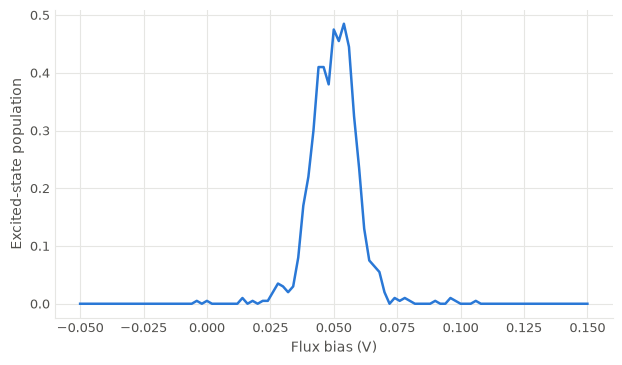

In [45]:
ported_result.plot(
    ported.measurement_handles()[0],
    field=MF.STATE,
    value=Quantity("Excited-state population"),
)

The peak sits at the bias `DEVICE` records, drawn out of a program with rack B's bus names and a library's pulses in it.

### 🧩 Exercise 5.1

Port the two-dimensional `arc` program to rack B. You have `arc` and `rack_b` in scope from 5.6 and 5.3.

1. Rebind it to the `drive_q0` naming convention with `BusNaming("{kind}_{element}{index}")`.
2. Print the bus strings before and after, to prove the names changed.
3. Validate the ported program against `rack_b` and compare the diagnostic codes to the original's.
4. Print `qp.explain(ported_arc, rack_b)` and find the bias sweep in the domain column.
5. Run `qp.optimize(ported_arc, rack_b)` and check whether the result differs from what went in. Say in a comment which diagnostic told you in advance that it would not.

The comparison in step 3 is the point. Renaming buses must not change what a rack thinks of the program, because the validator routes on the schema coordinate and not on the string. If the two lists of codes differed, `rebind` would be doing more than renaming, and every port here would be suspect.

In [ ]:
# TODO: port the `arc` program to rack B's naming convention and check it still validates.
# 1) ported_arc = arc.rebind(naming=BusNaming("{kind}_{element}{index}"))
# 2) print sorted(arc.buses) and sorted(ported_arc.buses).
# 3) print the diagnostic codes from qp.validate(arc, rack_b) and qp.validate(ported_arc, rack_b),
#    and confirm they match.
# 4) print(qp.explain(ported_arc, rack_b)) and find the bias sweep in the domain column.
# 5) Compare qp.dumps(qp.optimize(ported_arc, rack_b)) with qp.dumps(ported_arc), and say in a
#    comment which missing diagnostic predicted the result.

## Recap

- **The demand side is one call.** `node.required_capabilities()` answers for any node and `program.body.walk()` reaches every node, so the demand side of a whole validation is one loop. The node picks the profile its tokens are checked against, a block and a bus-less operation going to the platform slot and a bus-touching operation to its bus, and `expr.*` is the one prefix that routes on its own.
- **The supply side is a descriptor.** `qp.reference_capabilities()` with `dataclasses.replace` writes a rack down in one line, `qp.CompilerCapabilities.from_profile(name)` fetches a published half instead, and `qp.PlatformCapabilities(bus=..., platform=..., default_bus_profile=...)` assembles halves into a machine. Every slot is a `BusCapabilities` holding an `rt` half and a `host` half, and either may be `None`.
- **A descriptor says three things.** `capabilities` is a token set checked with `supports`, `limits` are the four numbers the validator compares a program against, and `predicates` are callables of `(node, ctx)` appended to one half of one slot.
- **A predicate yields one of two things.** A `Diagnostic` refuses, and a `DomainConstraint` names a binding loop and subtracts one domain from it, so the program still runs.
- **`qp.validate` returns `(diagnostics, plan)` and raises nothing.** A `Diagnostic` carries `severity`, `code`, `message`, `node`, and `path`, plus `capability` or `limit` when the check had one, and `qp.format_path`, `qp.node_path`, `qp.resolve_path`, and `program.source_map` take a path back to a line of a file.
- **`qp.explain` draws the plan.** One tree read `[rt|host]` against one descriptor, `[host]` against a second, and `[--]` against a third, off the same program every time.
- **`qp.optimize(program, caps)` applies the rewrite the plan suggests.** It swaps an averaging block with the flat sweep inside it and hoists the host-side setup out, it matches nothing when a second sweep is nested there, and a bare `program.sync()` blocks it by pulling every bus into one domain intersection.
- **Porting is `rebind` and `with_waveforms`.** `rebind(elements=...)` moves a program onto another qubit and `rebind(naming=...)` onto another spelling, both structurally, and a `WaveformLibrary` fills the aliases per bus. When the new rack drives a line with a different class of instrument, one more line changes, from `program.set_offset` to `program.qdac.set_offset`.

## Next

**Part 6, extending and shipping.** Instead of asking what a platform supports, you add to the language: your own waveform, your own sweep source, and a vendor namespace with its own operation and its own token.